# 05회 - 직원 이탈 예측

#### Q01.

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Q02.

In [91]:
churn_df = pd.read_csv('../datasets/employee_churn.csv')
churn_df.head()

,years_experience,salary,education_level,department,overtime,job_satisfaction,work_life_balance,attrition
0,15.0,54.6,master,finance,N,3,4,1
1,5.6,116.6,bachelor,hr,N,3,2,1
2,11.0,32.2,phd,hr,N,4,2,1
3,16.2,82.2,phd,sales,Y,1,3,1
4,12.4,97.7,high_school,engineering,N,2,3,1


#### Q03. 데이터 확인

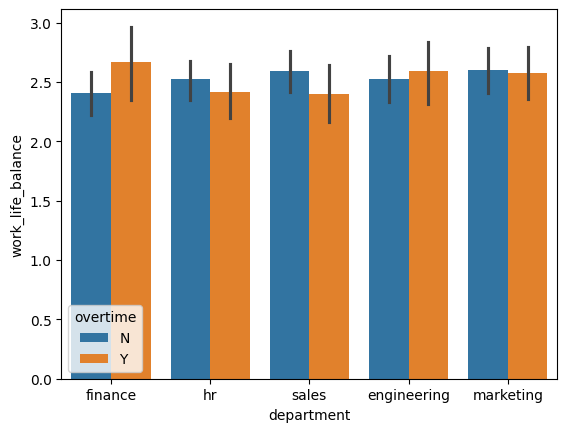

In [92]:
sns.barplot(
    data=churn_df, 
    x='department', 
    y='work_life_balance', 
    hue='overtime'
)
답03 = 2

#### Q04. 결측치 처리

In [93]:
churn_df.isnull().sum()
답04 = 'years_experience, salary'

pre_df = churn_df.drop(columns=['years_experience', 'salary'])
pre_df.reset_index(drop = True, inplace = True)
pre_df

,education_level,department,overtime,job_satisfaction,work_life_balance,attrition
0,master,finance,N,3,4,1
1,bachelor,hr,N,3,2,1
2,phd,hr,N,4,2,1
3,phd,sales,Y,1,3,1
4,high_school,engineering,N,2,3,1
...,...,...,...,...,...,...
1095,high_school,hr,Y,2,2,0
1096,high_school,marketing,N,2,4,0
1097,master,finance,Y,3,3,0
1098,bachelor,engineering,Y,3,4,0


#### Q05. Groupby를 이용한 데이터 확인

In [94]:
pre_df.groupby('department')['job_satisfaction'].mean()
#답05 = 4

department
engineering    2.473934
finance        2.545872
hr             2.545455
marketing      2.579439
sales          2.506977
Name: job_satisfaction, dtype: float64

#### Q06. crosstab을 이용한 데이터 확인

In [95]:
pd.crosstab(pre_df['department'], pre_df['attrition'], normalize='index').round(2)
# 답06 = 'engineering'

attrition,0,1
department,,
engineering,0.62,0.38
finance,0.67,0.33
hr,0.65,0.35
marketing,0.67,0.33
sales,0.73,0.27


#### Q07. 범주형 변수 인코딩

In [96]:
pre_df.head()

,education_level,department,overtime,job_satisfaction,work_life_balance,attrition
0,master,finance,N,3,4,1
1,bachelor,hr,N,3,2,1
2,phd,hr,N,4,2,1
3,phd,sales,Y,1,3,1
4,high_school,engineering,N,2,3,1


In [97]:
edu_map = {
    'high_school': 0,
    'bachelor': 1,
    'master': 2,
    'phd': 3
}
pre_df['education_level'] = pre_df['education_level'].map(edu_map)

In [98]:
pre_df.head()

,education_level,department,overtime,job_satisfaction,work_life_balance,attrition
0,2,finance,N,3,4,1
1,1,hr,N,3,2,1
2,3,hr,N,4,2,1
3,3,sales,Y,1,3,1
4,0,engineering,N,2,3,1


In [99]:
encoding_df = pd.get_dummies(data=pre_df, columns=['department'], drop_first=True)
encoding_df['overtime'] = np.where(encoding_df['overtime'] == 'Y', 1, 0)
encoding_df

,education_level,overtime,job_satisfaction,work_life_balance,attrition,department_finance,department_hr,department_marketing,department_sales
0,2,0,3,4,1,True,False,False,False
1,1,0,3,2,1,False,True,False,False
2,3,0,4,2,1,False,True,False,False
3,3,1,1,3,1,False,False,False,True
4,0,0,2,3,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1095,0,1,2,2,0,False,True,False,False
1096,0,0,2,4,0,False,False,True,False
1097,2,1,3,3,0,True,False,False,False
1098,1,1,3,4,0,False,False,False,False


#### Q08.

In [100]:
X = encoding_df.drop(columns=['attrition'])
y = encoding_df['attrition']

#### Q09.

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42)

#### Q10.

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

#### Q11.

In [105]:
from lightgbm import LGBMClassifier

In [109]:
lgbmc = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.01,
    random_state=10
)

lgbmc.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 286, number of negative: 594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30
[LightGBM] [Info] Number of data points in the train set: 880, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.325000 -> initscore=-0.730888
[LightGBM] [Info] Start training from score -0.730888
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Q12.

In [110]:
from xgboost import XGBClassifier

In [113]:
xgbc = XGBClassifier(
    n_estimators=200, 
    max_depth=8, 
    learning_rate=0.1, 
    random_state=10
)

xgbc.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#### Q13.

In [114]:
from sklearn.metrics import accuracy_score, f1_score

In [121]:
lgbmc_predict = lgbmc.predict(X_test)
xgbc_predict = xgbc.predict(X_test)

print("LightGBM")
print("Accuracy:", accuracy_score(y_valid, lgbmc_predict))
print("F1 Score:", f1_score(y_valid, lgbmc_predict))

print("XGBoost")
print("Accuracy:", accuracy_score(y_valid, xgbc_predict))
print("F1 Score:", f1_score(y_valid, xgbc_predict))

LightGBM
Accuracy: 0.6409090909090909
F1 Score: 0.0
XGBoost
Accuracy: 0.5
F1 Score: 0.22535211267605634


d:\dev\workspace\ai\aice_associate\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Q14.

In [122]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(10)
y_train = to_categorical(y_train, num_classes=2)
y_valid = to_categorical(y_valid, num_classes=2)

In [125]:
model = Sequential()
model.add(Dense(64, activation='selu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=["accuracy"]
)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32
)

d:\dev\workspace\ai\aice_associate\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5216 - loss: 0.7812
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6420 - loss: 0.6479
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6659 - loss: 0.6307
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6773 - loss: 0.6203
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6773 - loss: 0.6126
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6864 - loss: 0.6066
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6898 - loss: 0.6013
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6955 - loss: 0.5973
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6943 - loss: 0.5933
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7000 - loss: 0.5895
Epoch 11/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7034 - loss: 0.5860
Epoch 12/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7023 - 